### Transformation = To make data into normal distribution
##### some ml algo works better on data when we use logistic and linear algorithms wee need to use Transformation to make data normally distributed.

In [44]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

# Log Transformation

### Log transform used in Right skeweed data.

#### Huge values (1,10,100,1000) in linear scale when we use log it comes near in same scale. and then linear and logistic regression peroforms well.

In [45]:
df = pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/covid_dataset.csv',usecols=['Age','Fever','Has_Covid'])

In [46]:
df

,Age,Fever,Has_Covid
0,56,102.4,No
1,19,101.6,No
2,76,102.0,No
3,65,99.7,No
4,25,102.1,Yes
...,...,...,...
995,41,102.0,No
996,76,100.9,No
997,35,100.6,No
998,13,99.5,Yes


In [47]:
x = df.iloc[:,0:2]
y = df.iloc[:,2:3]

In [48]:
x

,Age,Fever
0,56,102.4
1,19,101.6
2,76,102.0
3,65,99.7
4,25,102.1
...,...,...
995,41,102.0
996,76,100.9
997,35,100.6
998,13,99.5


In [49]:
y

,Has_Covid
0,No
1,No
2,No
3,No
4,Yes
...,...
995,No
996,No
997,No
998,Yes


In [50]:
x_train ,x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

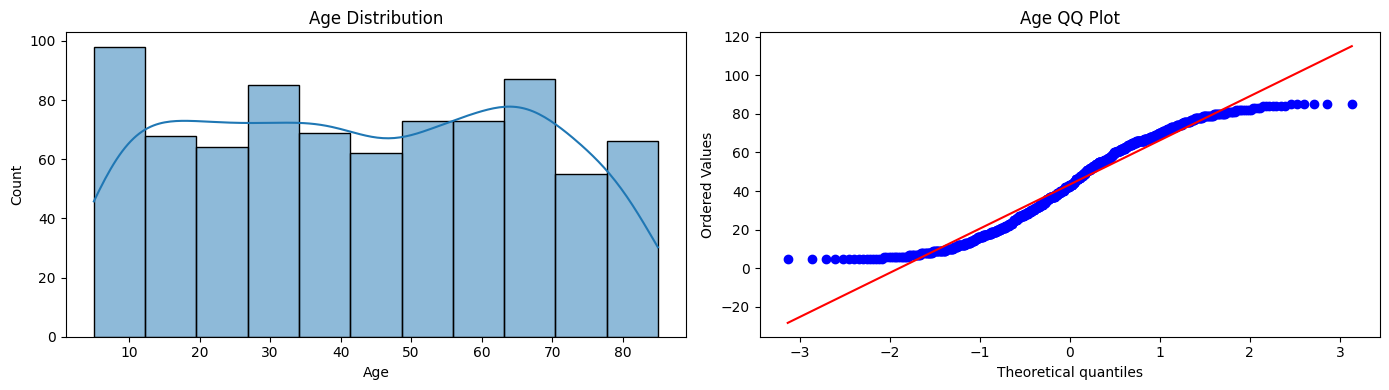

In [51]:


plt.figure(figsize=(14,4))

# PDF (Histogram)
plt.subplot(121)
sns.histplot(x_train['Age'], kde=True)
plt.title('Age Distribution')

# QQ Plot
plt.subplot(122)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.tight_layout()
plt.show()

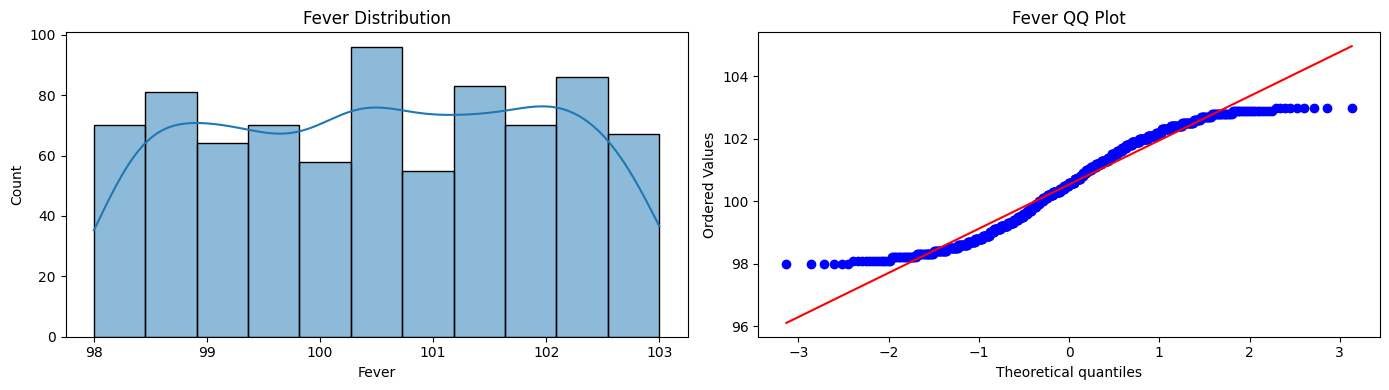

In [52]:
plt.figure(figsize=(14,4))

# PDF (Histogram)
plt.subplot(121)
sns.histplot(x_train['Fever'], kde=True)
plt.title('Fever Distribution')

# QQ Plot
plt.subplot(122)
stats.probplot(x_train['Fever'], dist="norm", plot=plt)
plt.title('Fever QQ Plot')

plt.tight_layout()
plt.show()

In [53]:
clf = LogisticRegression()
clf1= DecisionTreeClassifier()

In [54]:
clf.fit(x_train, y_train)
clf1.fit(x_train, y_train)

y_pred = clf.predict(x_test)
y_pred1 = clf1.predict(x_test)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.545
Accuracy DT 0.47


/opt/anaconda3/envs/DS/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [55]:
trf1 = FunctionTransformer(func=np.log1p)

In [56]:
x_train_transformed = trf1.fit_transform(x_train)
x_test_transformed = trf1.fit_transform(x_test)


In [57]:
clf.fit(x_train_transformed, y_train)
clf1.fit(x_train_transformed, y_train)

y_pred = clf.predict(x_test_transformed)
y_pred1 = clf1.predict(x_test_transformed)

print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.56
Accuracy DT 0.44


/opt/anaconda3/envs/DS/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [60]:
x_transformed = trf1.fit_transform(x)

clf = LogisticRegression()
clf1= DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, x_transformed, y, scoring='accuracy',cv=10)))
print("DR", np.mean(cross_val_score(clf1, x_transformed, y, scoring='accuracy',cv=10)))

LR 0.5119999999999999
DR 0.481


/opt/anaconda3/envs/DS/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/DS/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/DS/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/DS/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please 

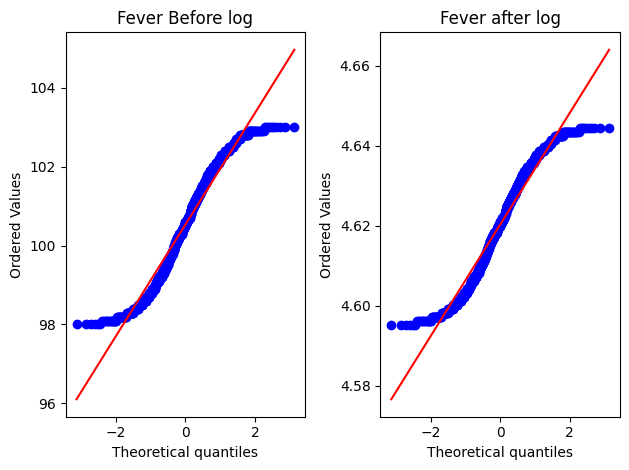

In [62]:
plt.subplot(121)
stats.probplot(x_train['Fever'], dist="norm", plot=plt)
plt.title('Fever Before log')

plt.subplot(122)
stats.probplot(x_train_transformed['Fever'], dist="norm", plot=plt)
plt.title('Fever after log')

plt.tight_layout()
plt.show()

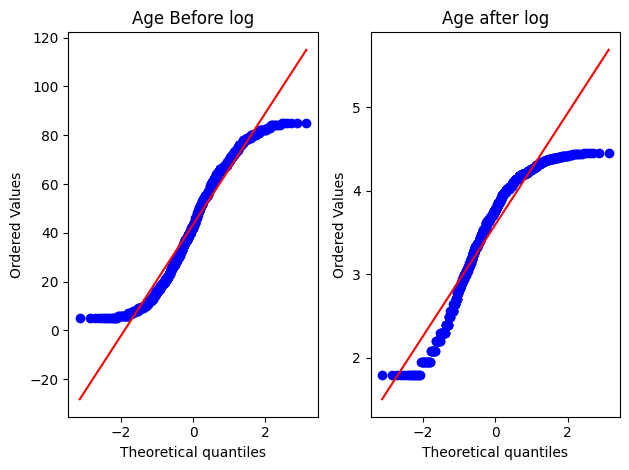

In [63]:
plt.subplot(121)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age Before log')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age after log')

plt.tight_layout()
plt.show()